# Image Enhancement from Scratch

In [1]:
import os
import glob
import math
import cmath
from PIL import Image
import matplotlib.pyplot as plt

ROOT = os.getcwd()

def clip(value, low=0, high=255):
    return max(low, min(high, value))

def make_histogram(image):
    hist = [0] * 256
    for row in image:
        for pixel in row:
            hist[int(clip(round(pixel)))] += 1
    return hist

def show_image_histogram(image, title, cmap='gray'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(image, cmap=cmap, vmin=0, vmax=255)
    axes[0].set_title(title)
    axes[0].axis('off')
    axes[1].plot(make_histogram(image), color='black')
    axes[1].set_title('Histogram')
    axes[1].set_xlim(0, 255)
    axes[1].set_xlabel('Intensity')
    axes[1].set_ylabel('Pixel count')
    plt.tight_layout()
    plt.show()

def show_comparison(original, result, title):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255); axes[0, 0].set_title('Input grayscale')
    axes[0, 1].imshow(result, cmap='gray', vmin=0, vmax=255); axes[0, 1].set_title(title)
    axes[1, 0].plot(make_histogram(original), color='black'); axes[1, 0].set_title('Input histogram')
    axes[1, 1].plot(make_histogram(result), color='black'); axes[1, 1].set_title('Result histogram')
    for axis in axes[0]: axis.axis('off')
    for axis in axes[1]: axis.set_xlim(0, 255)
    plt.tight_layout(); plt.show()

def convolve(image, kernel, divisor=1, offset=0):
    height, width = len(image), len(image[0])
    kh, kw = len(kernel), len(kernel[0])
    cy, cx = kh // 2, kw // 2
    result = []
    for y in range(height):
        row = []
        for x in range(width):
            total = 0
            for ky in range(kh):
                for kx in range(kw):
                    yy = min(height - 1, max(0, y + ky - cy))
                    xx = min(width - 1, max(0, x + kx - cx))
                    total += image[yy][xx] * kernel[ky][kx]
            row.append(clip(total / divisor + offset))
        result.append(row)
    return result

def resize_nearest(image, new_height, new_width):
    height, width = len(image), len(image[0])
    return [[image[min(height - 1, int(y * height / new_height))][min(width - 1, int(x * width / new_width))] for x in range(new_width)] for y in range(new_height)]

In [2]:
def load_grayscale(path, max_size=256):
    source = Image.open(path).convert('RGB')
    width, height = source.size
    scale = min(1.0, max_size / max(width, height))
    target_width, target_height = max(1, int(width * scale)), max(1, int(height * scale))
    pixels = source.load()
    image = []
    for y in range(target_height):
        row = []
        for x in range(target_width):
            sx = min(width - 1, int(x / scale))
            sy = min(height - 1, int(y / scale))
            red, green, blue = pixels[sx, sy]
            row.append(0.299 * red + 0.587 * green + 0.114 * blue)
        image.append(row)
    return image

## Spatial domain: intensity transformation

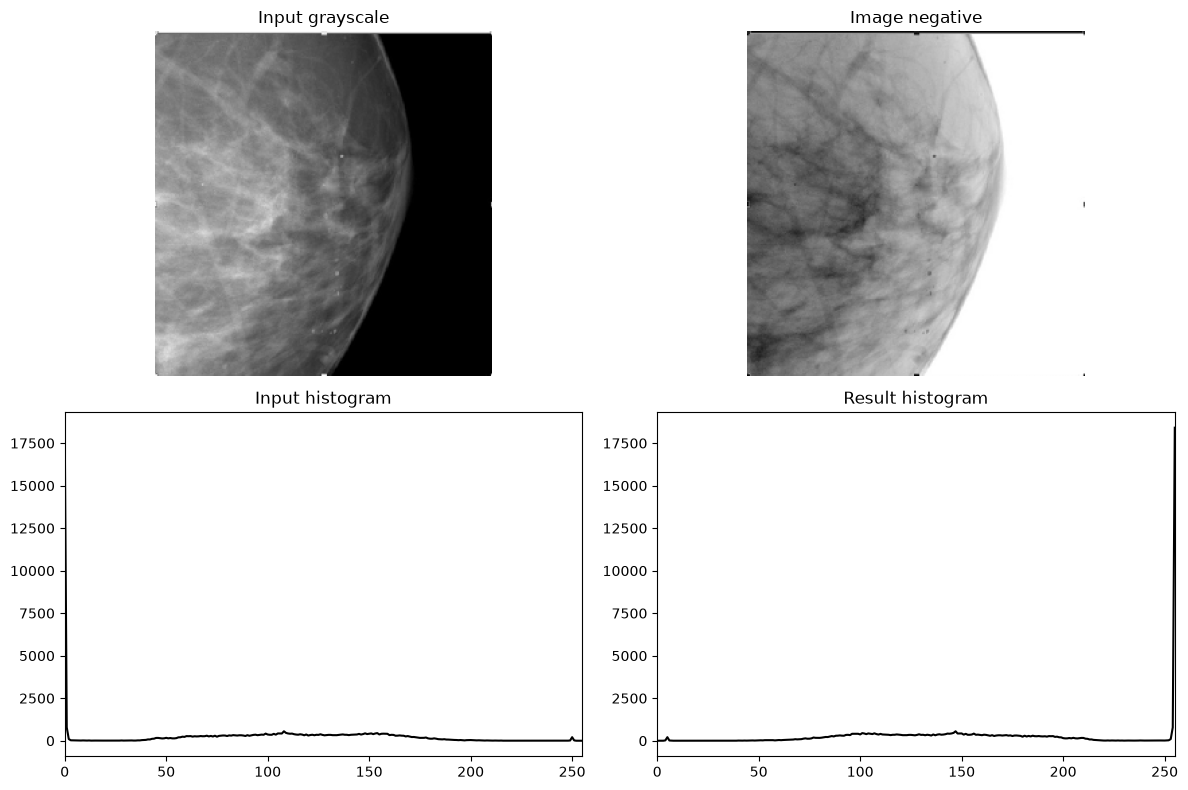

In [3]:
#Image negative
gray = load_grayscale('mammo.jpg')
negative = [[255 - pixel for pixel in row] for row in gray]
show_comparison(gray, negative, 'Image negative')

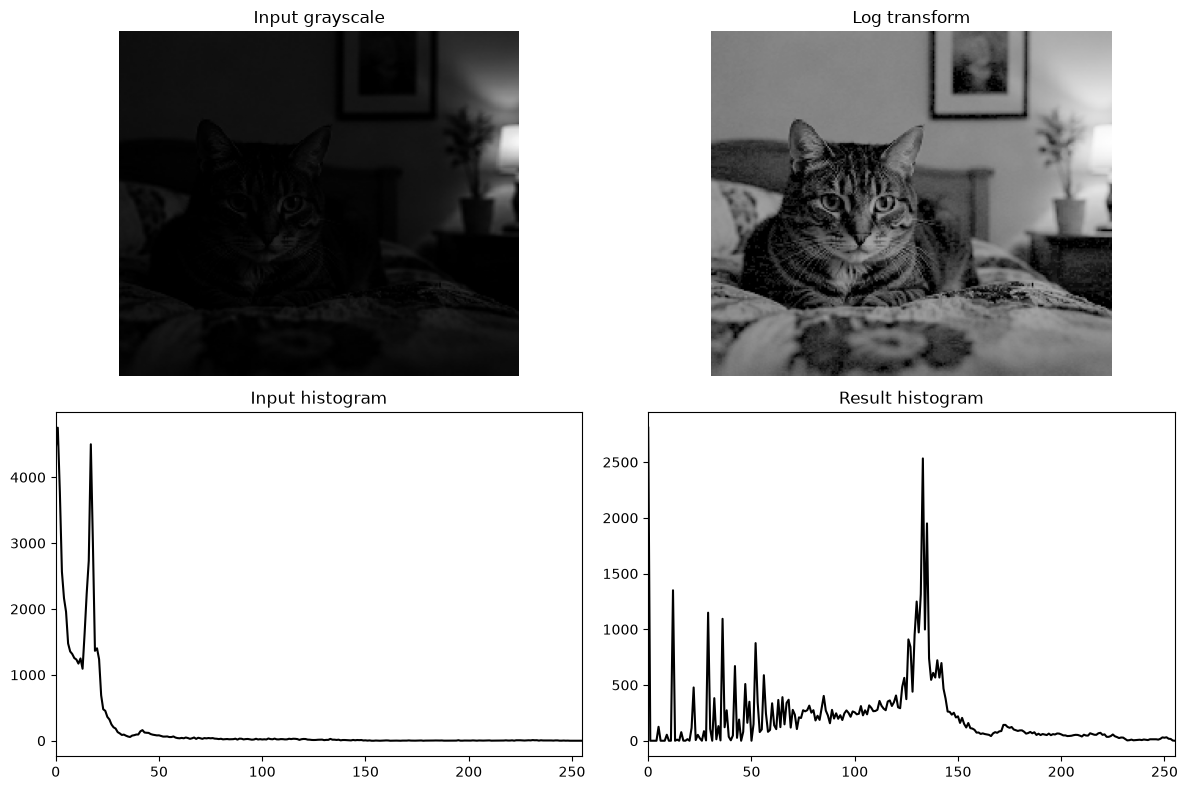

In [4]:
# Log transform
gray = load_grayscale('dark.png')
c_log = 255 / math.log(256)
log_image = [[clip(c_log * math.log(1 + pixel)) for pixel in row] for row in gray]
show_comparison(gray, log_image, 'Log transform')

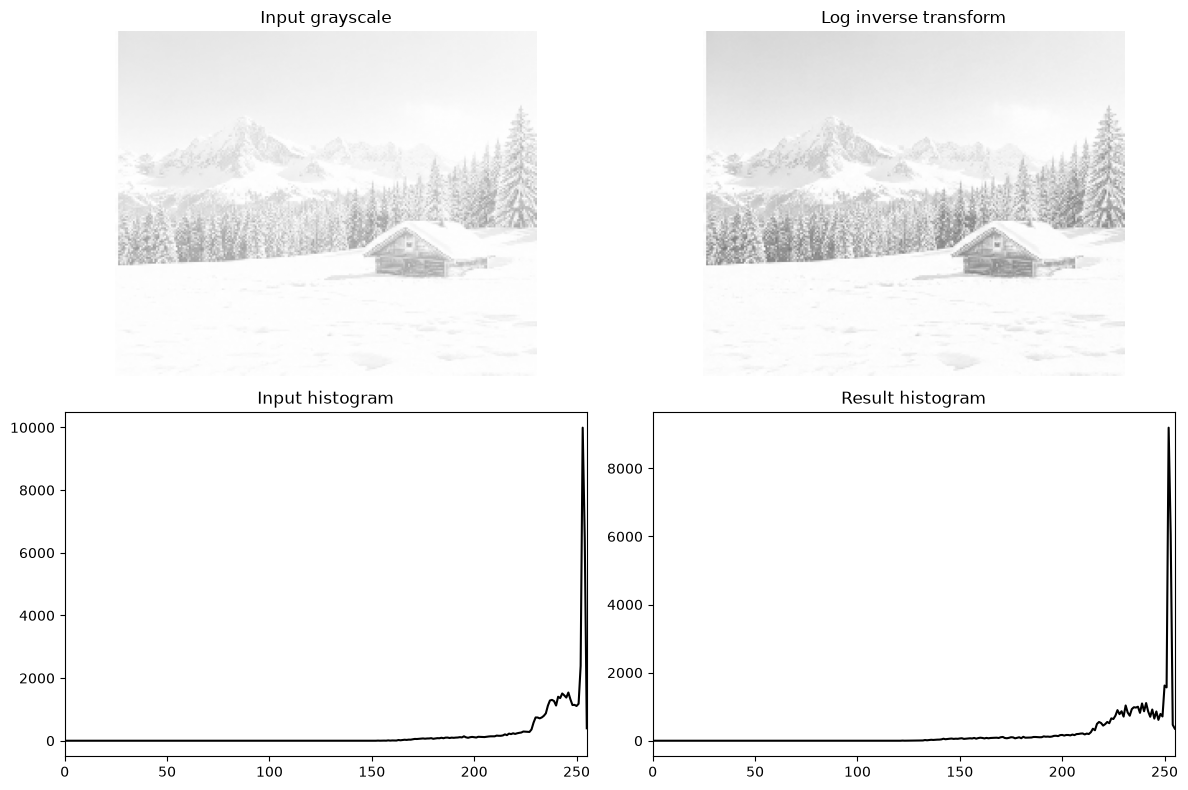

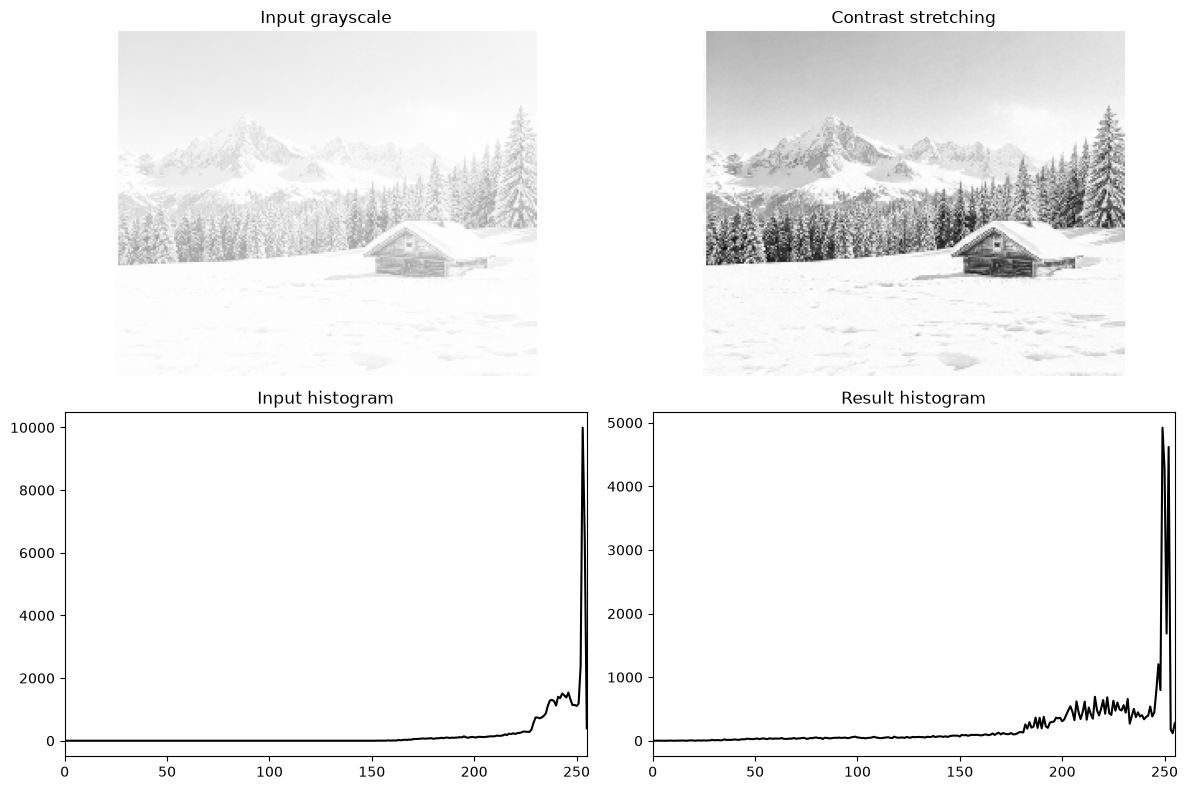

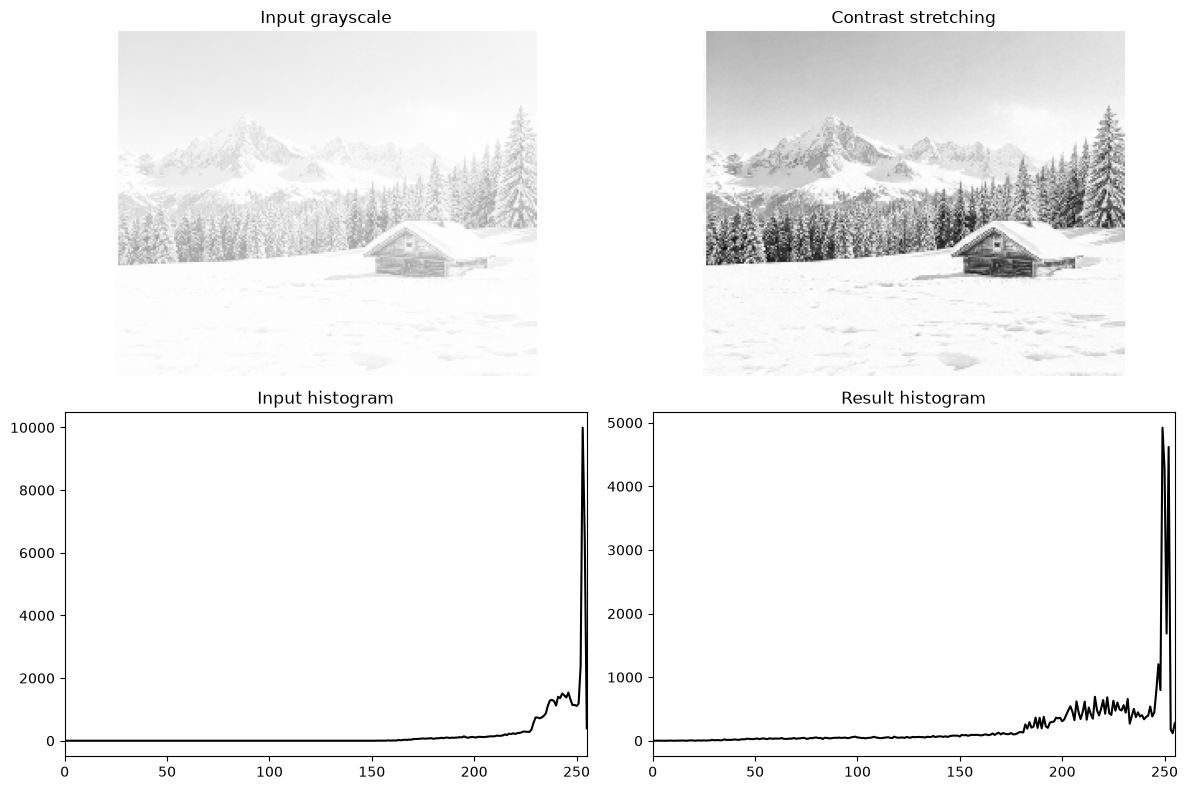

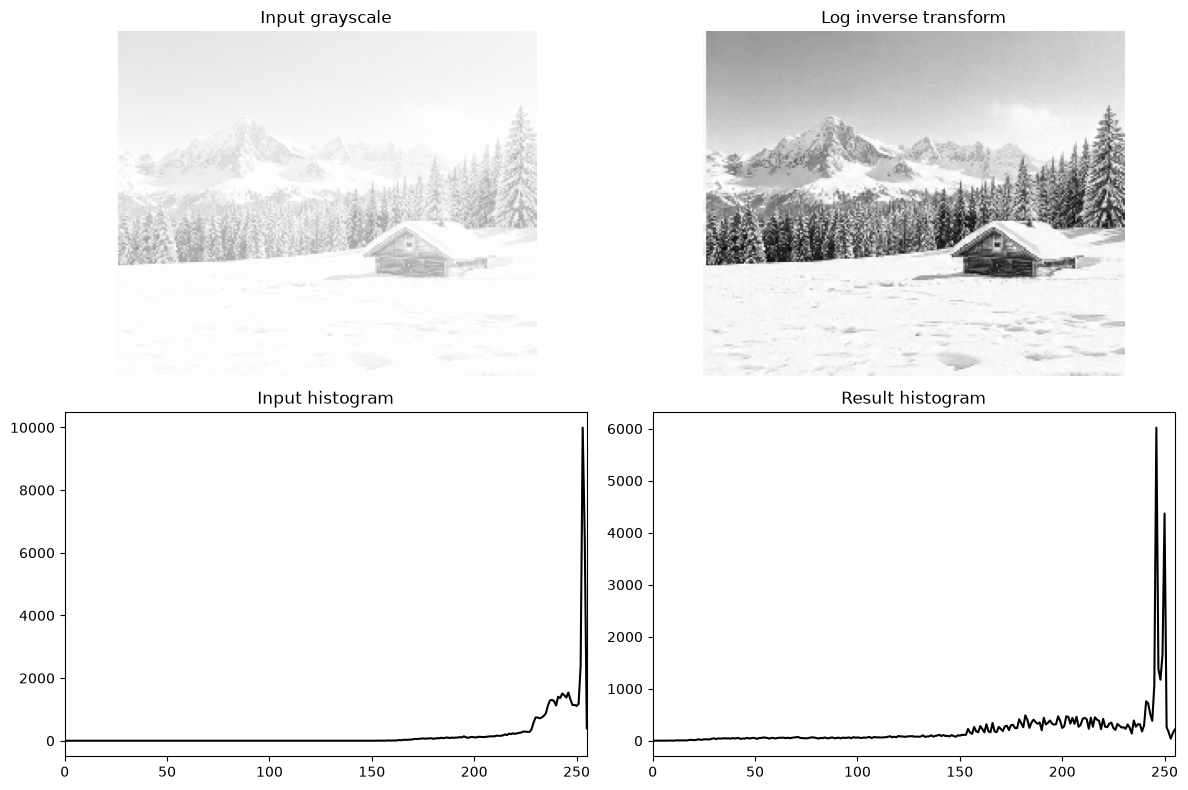

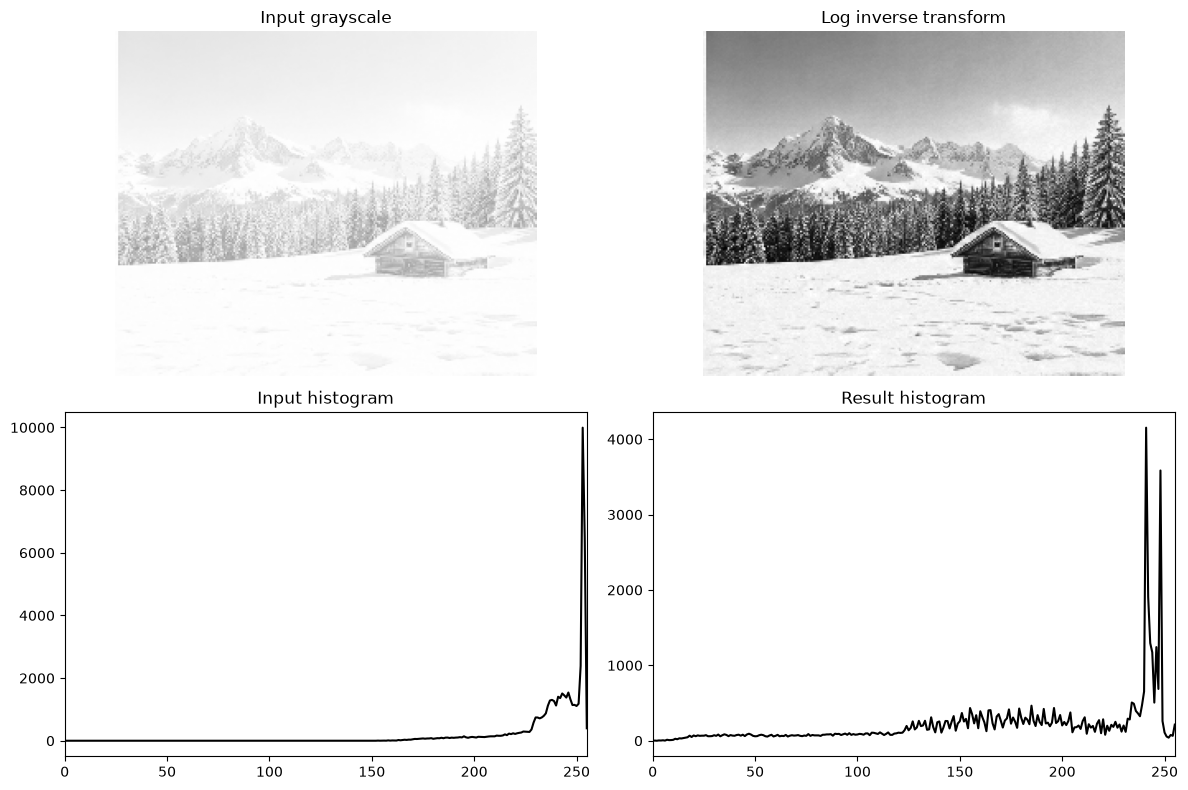

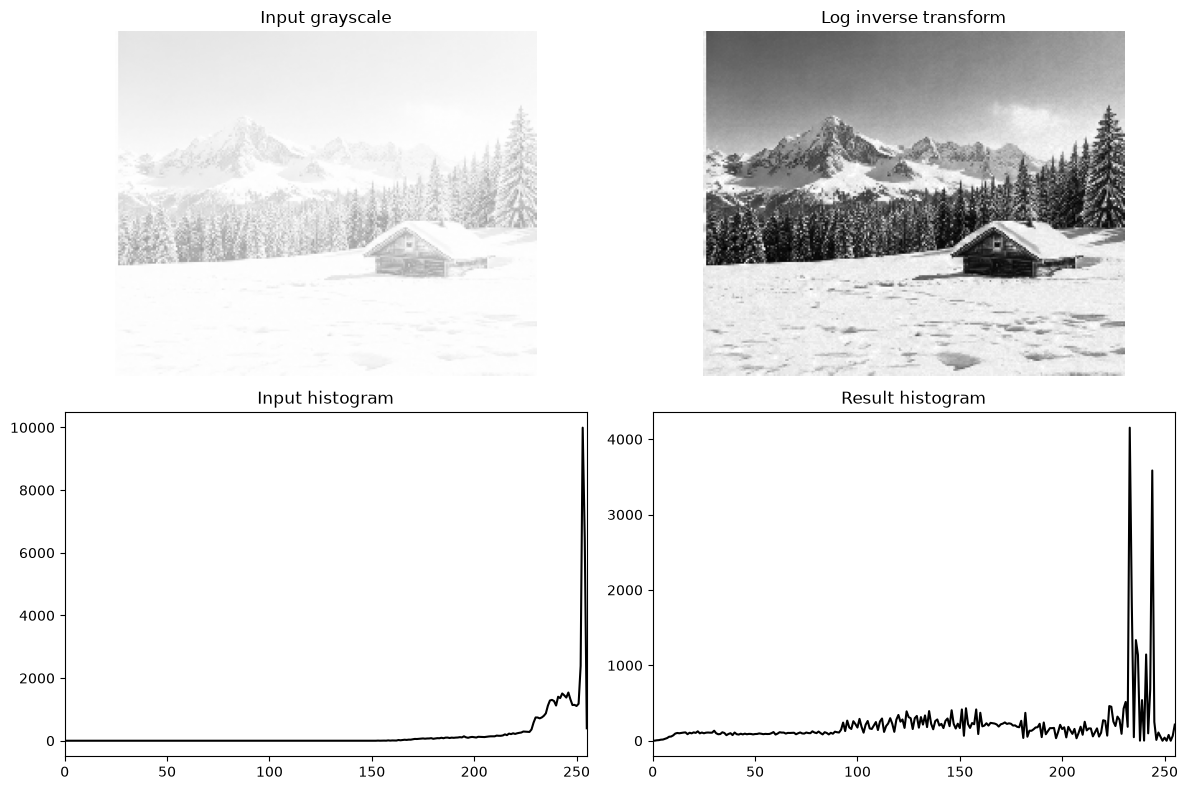

In [5]:
# Log inverse transform
gray = load_grayscale('bright.png')
c_inverse = 255 / (math.exp(1) - 1)
inverse_log = [[clip(c_inverse * (math.exp(pixel / 255) - 1)) for pixel in row] for row in gray]
show_comparison(gray, inverse_log, 'Log inverse transform')

# Cell 6 - Piecewise-linear transform dan contrast stretching
low = min(min(row) for row in inverse_log); high = max(max(row) for row in inverse_log)
contrast_stretched = [[clip((pixel - low) * 255 / (high - low)) if high > low else pixel for pixel in row] for row in inverse_log]
show_comparison(gray, contrast_stretched, 'Contrast stretching')

low = min(min(row) for row in contrast_stretched); high = max(max(row) for row in contrast_stretched)
contrast_stretched2 = [[clip((pixel - low) * 255 / (high - low)) if high > low else pixel for pixel in row] for row in contrast_stretched]
show_comparison(gray, contrast_stretched2, 'Contrast stretching')

inverse_log2 = [[clip(c_inverse * (math.exp(pixel / 255) - 1)) for pixel in row] for row in contrast_stretched2]
show_comparison(gray, inverse_log2, 'Log inverse transform')

inverse_log3 = [[clip(c_inverse * (math.exp(pixel / 255) - 1)) for pixel in row] for row in inverse_log2]
show_comparison(gray, inverse_log3, 'Log inverse transform')

inverse_log4 = [[clip(c_inverse * (math.exp(pixel / 255) - 1)) for pixel in row] for row in inverse_log3]
show_comparison(gray, inverse_log4, 'Log inverse transform')

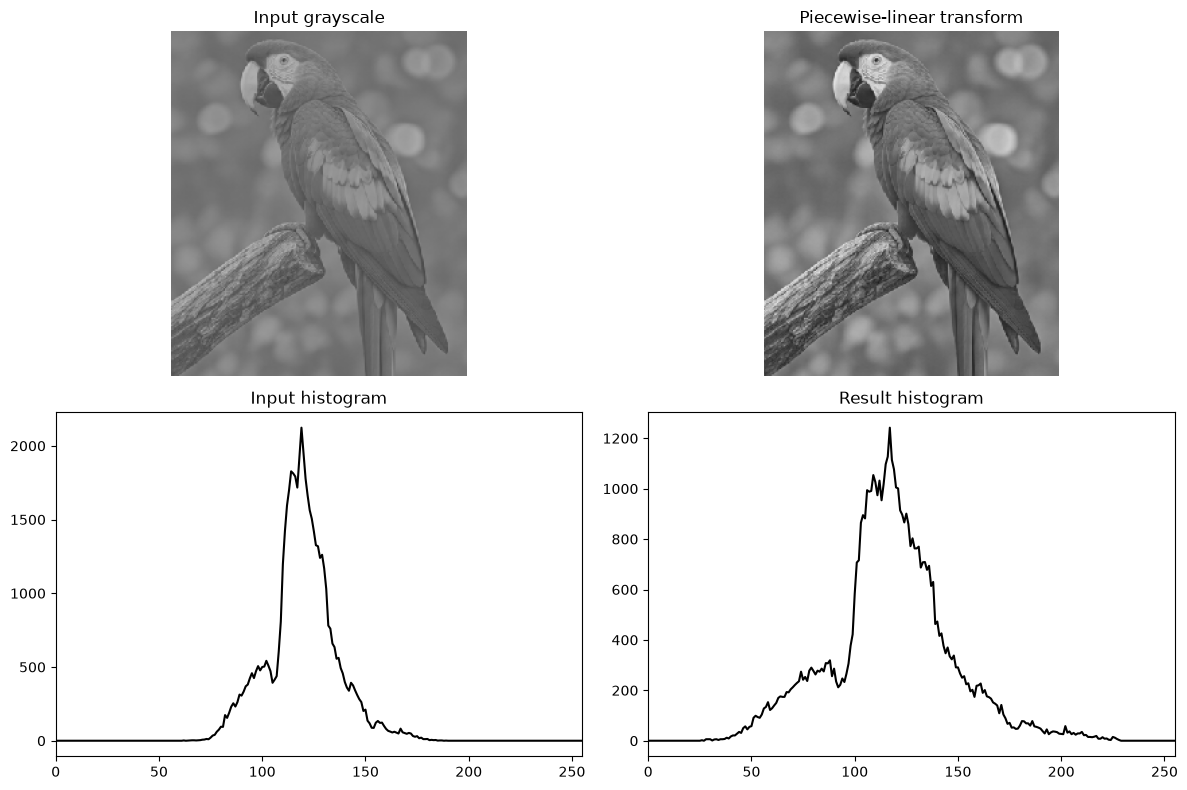

In [6]:
# Cell 6 - Piecewise-linear transform dan contrast stretching
def piecewise_linear(pixel, r1=70, s1=30, r2=180, s2=225):
    if pixel <= r1: return s1 * pixel / r1
    if pixel <= r2: return s1 + (s2 - s1) * (pixel - r1) / (r2 - r1)
    return s2 + (255 - s2) * (pixel - r2) / (255 - r2)

gray = load_grayscale('lowcontrast.png')
piecewise = [[clip(piecewise_linear(pixel)) for pixel in row] for row in gray]

show_comparison(gray, piecewise, 'Piecewise-linear transform')

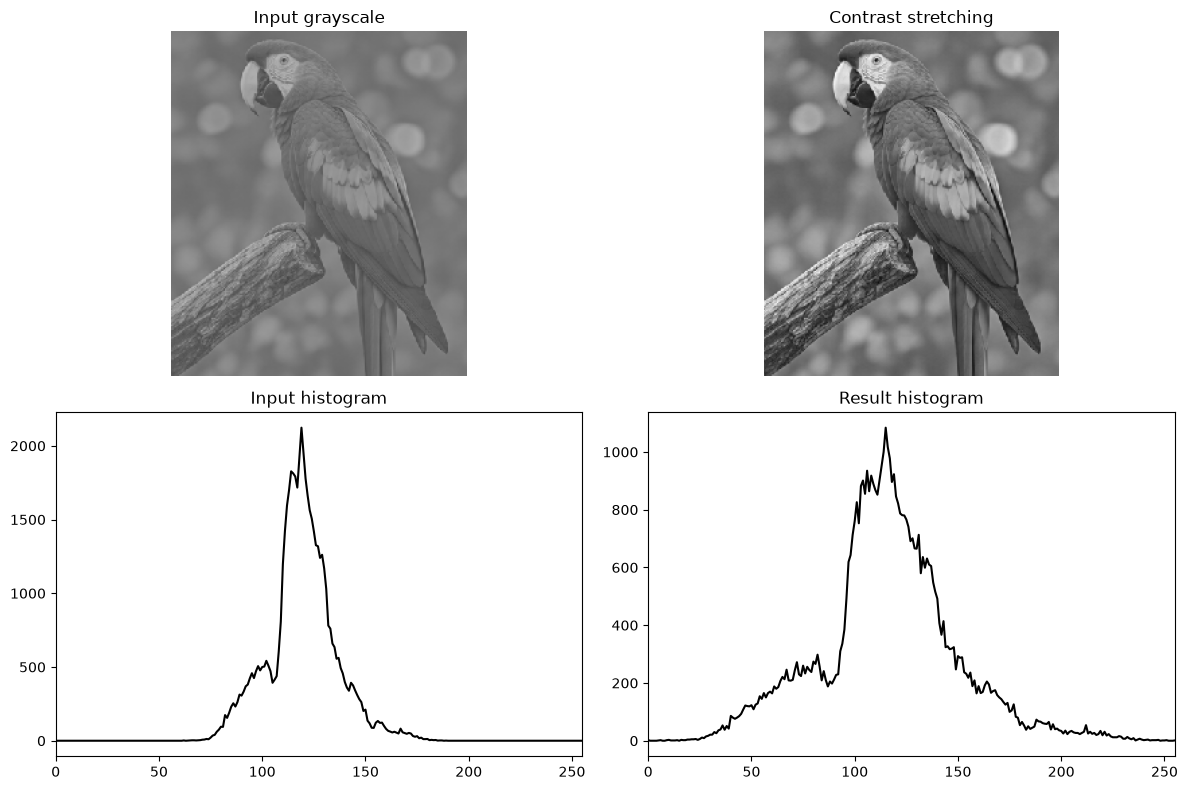

In [7]:
low = min(min(row) for row in gray); high = max(max(row) for row in gray)
contrast_stretched = [[clip((pixel - low) * 255 / (high - low)) if high > low else pixel for pixel in row] for row in gray]
show_comparison(gray, contrast_stretched, 'Contrast stretching')

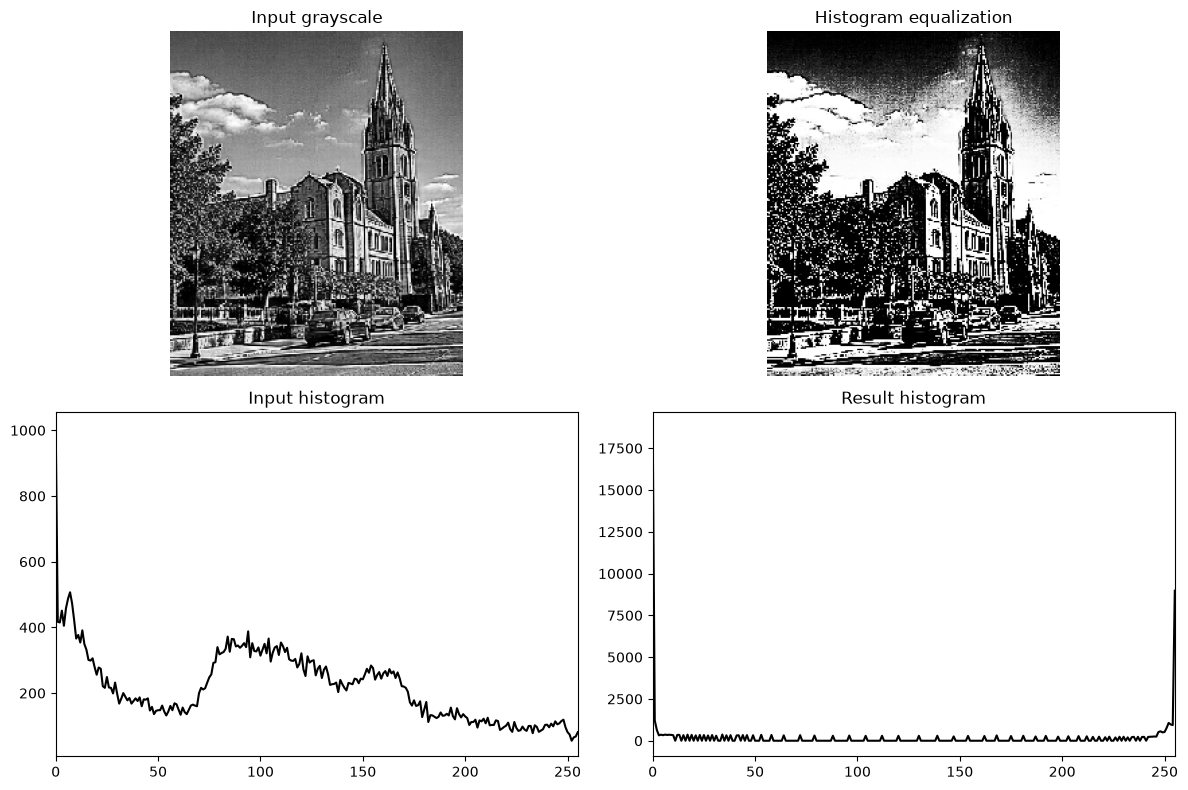

In [8]:
# Cell 8 - Histogram equalization
hist = make_histogram(gray)
total_pixels = len(gray) * len(gray[0])
cdf = []; running = 0
for count in hist:
    running += count; cdf.append(running)
cdf_min = next(value for value in cdf if value > 0)

gray = load_grayscale('toosharpened.png')
equalized = [[clip(round((cdf[int(pixel)] - cdf_min) * 255 / max(1, total_pixels - cdf_min))) for pixel in row] for row in gray]
show_comparison(gray, equalized, 'Histogram equalization')

## Spatial domain: linear and nonlinear filtering

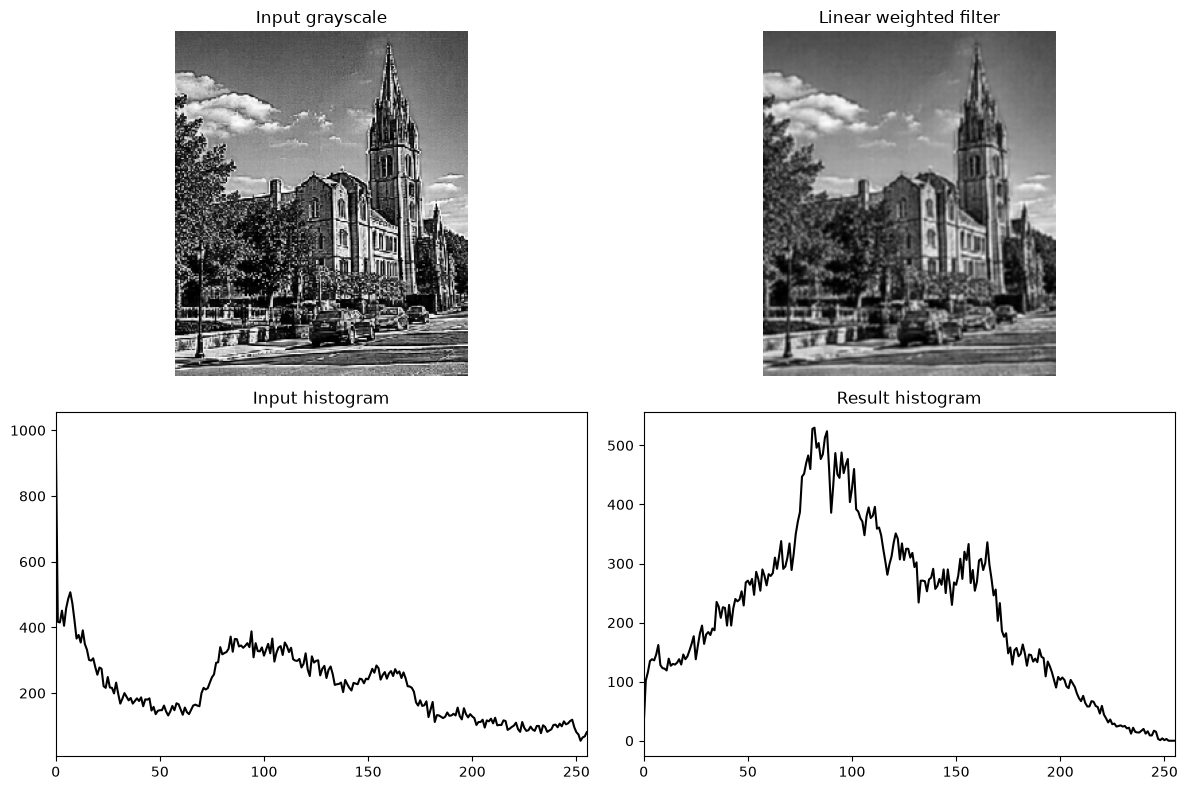

In [9]:
# Cell 9 - Linear filter umum
linear_kernel = [
                    [1, 2, 1], 
                    [2, 4, 2], 
                    [1, 2, 1]
                    ]
gray = load_grayscale('toosharpened.png')
linear_filtered = convolve(gray, linear_kernel, divisor=16)
show_comparison(gray, linear_filtered, 'Linear weighted filter')

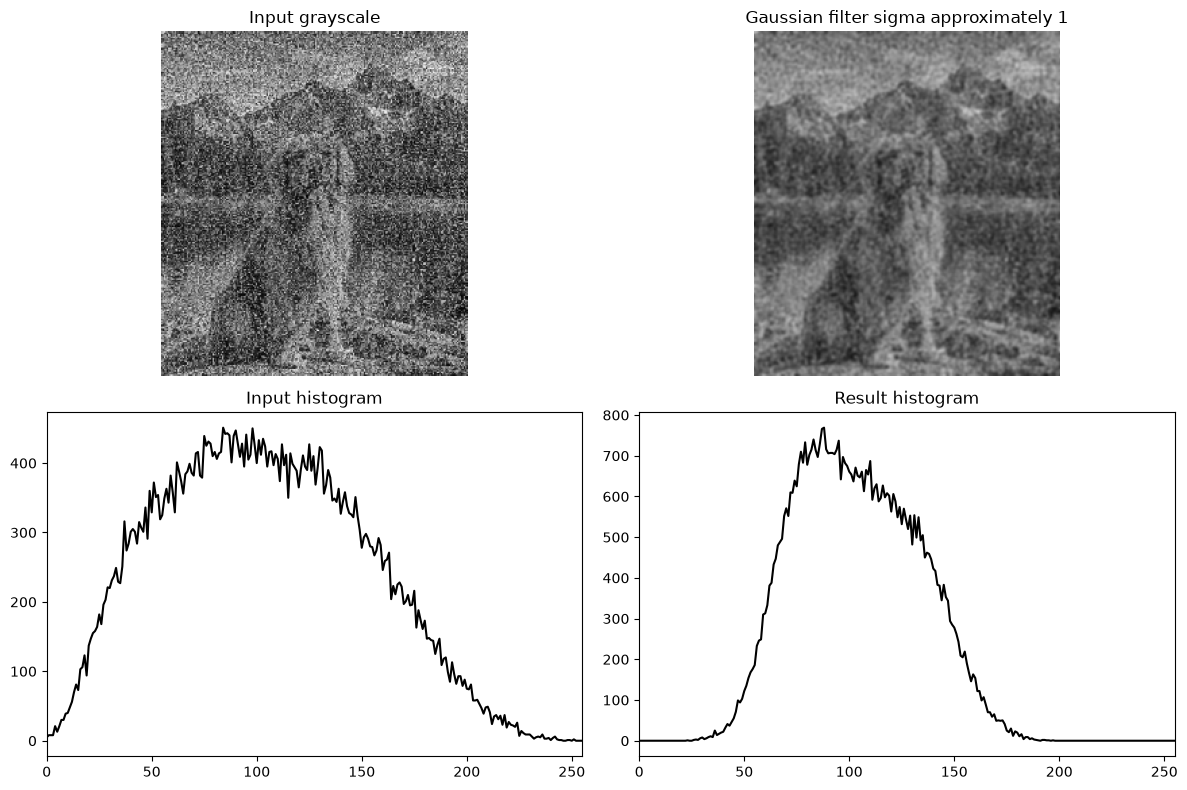

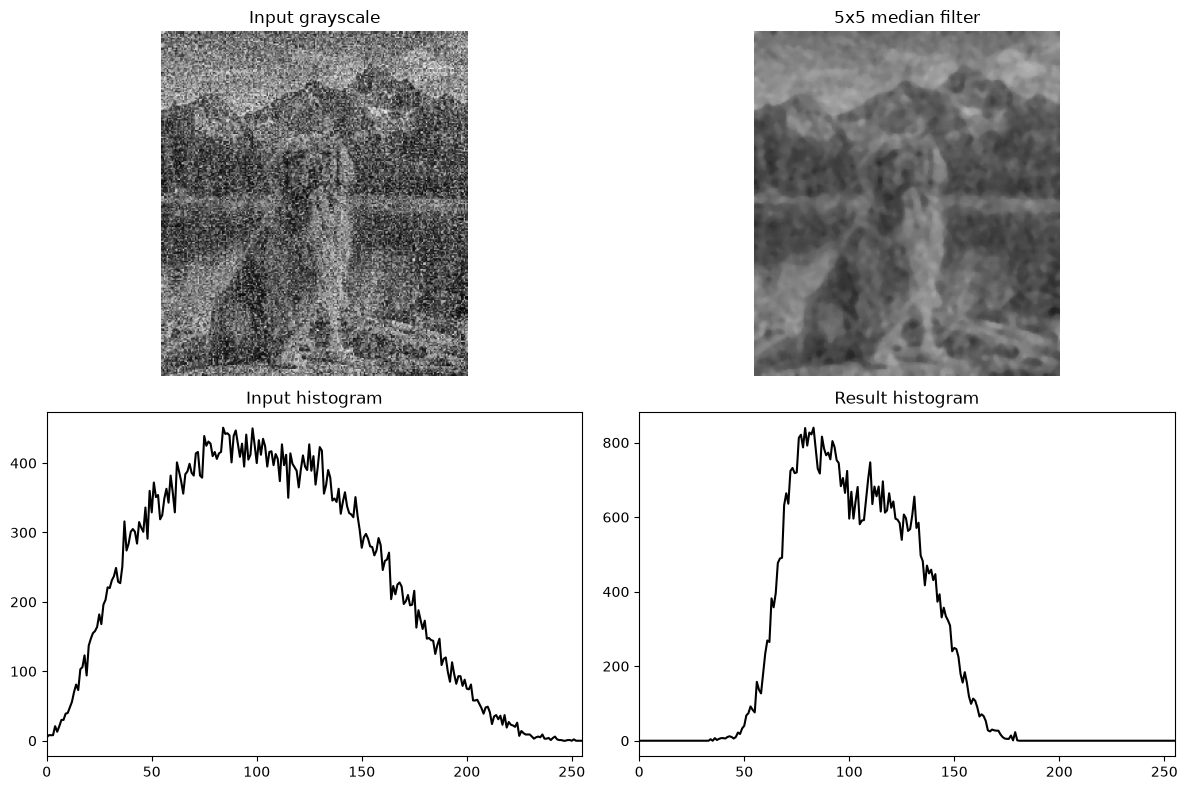

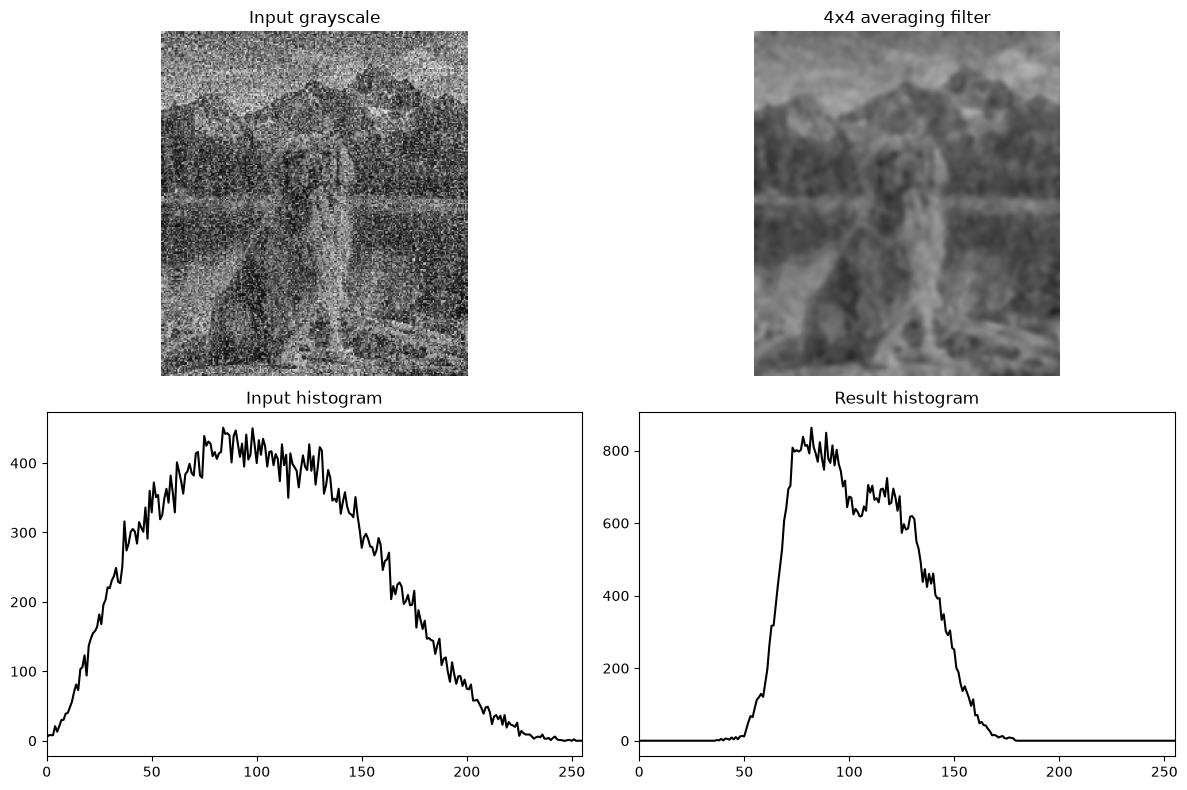

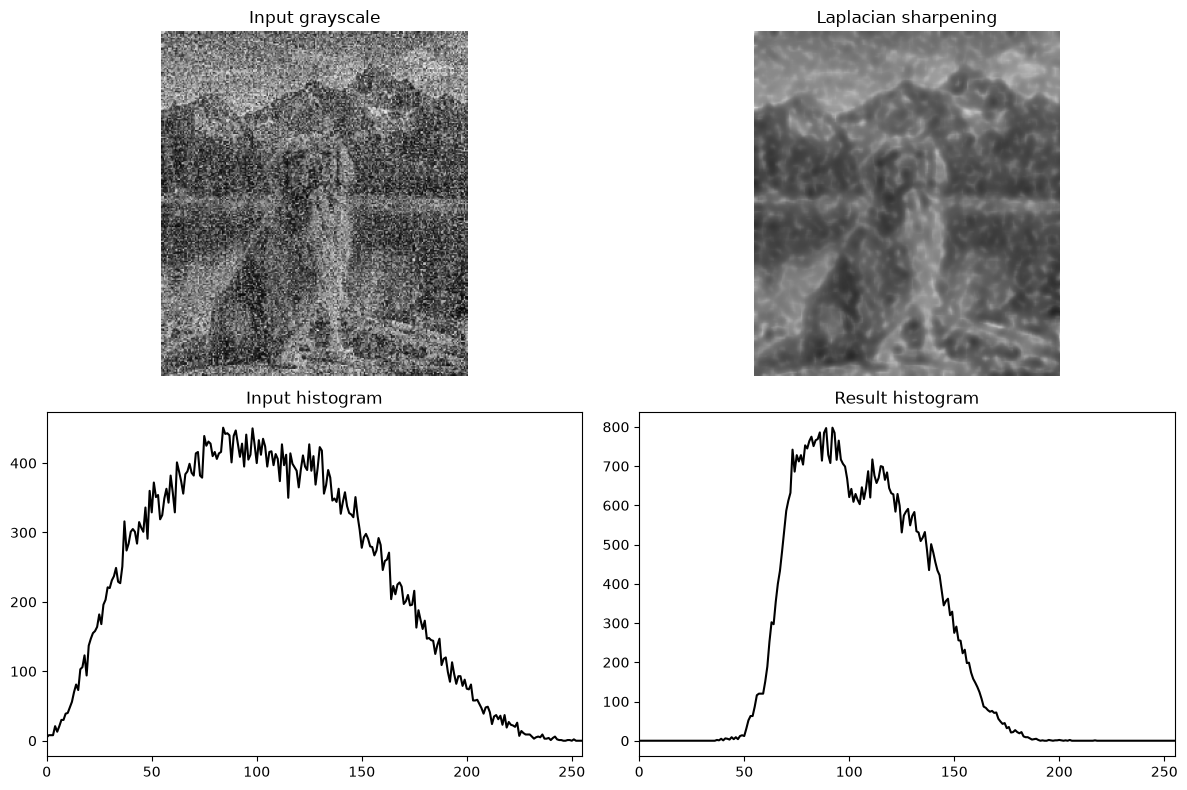

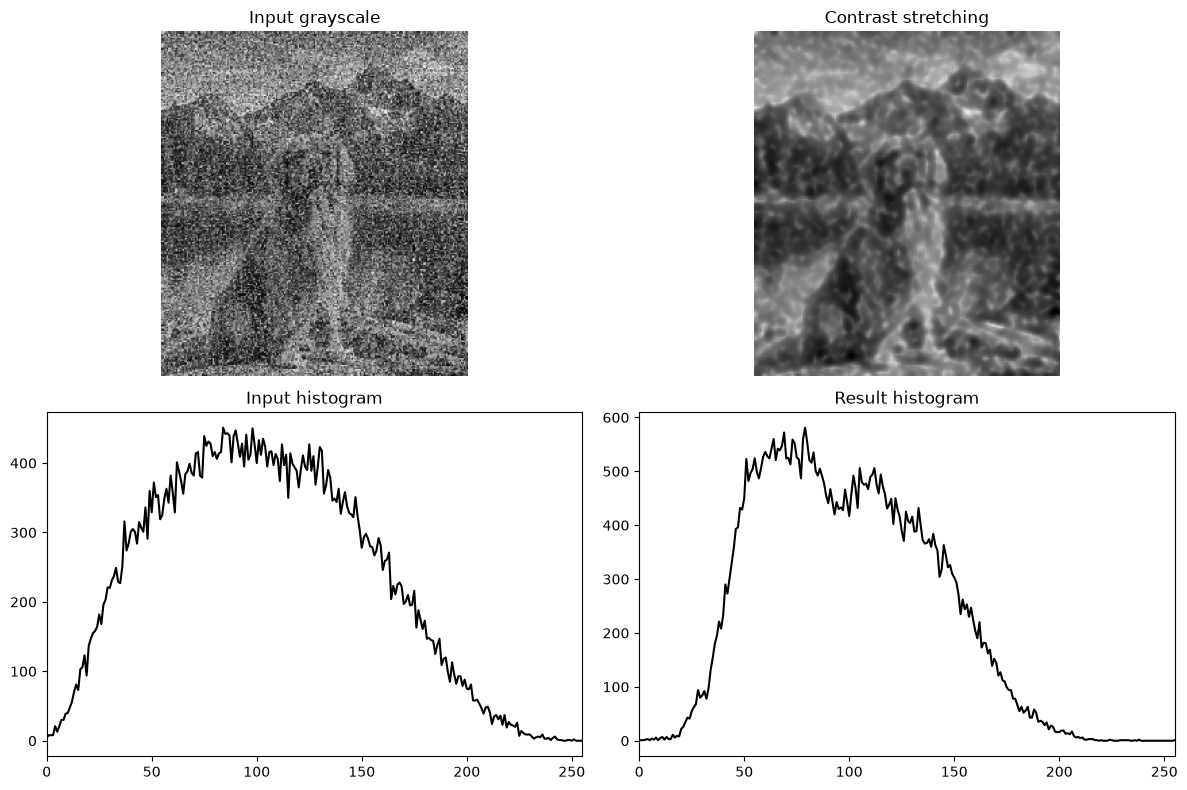

In [10]:
# Cell 11 - Gaussian filtering
gaussian_kernel = [
    [1, 4, 7, 4, 1], 
    [4, 16, 26, 16, 4], 
    [7, 26, 41, 26, 7],
    [4, 16, 26, 16, 4],
    [1, 4, 7, 4, 1]]

gray = load_grayscale('noise.png')
gaussian_filtered = convolve(gray, gaussian_kernel, divisor=273)
show_comparison(gray, gaussian_filtered, 'Gaussian filter sigma approximately 1')

# Cell 12 - Median filter
def median_filter(image, size=5):
    height, width = len(image), len(image[0]); radius = size // 2
    result = []
    for y in range(height):
        row = []
        for x in range(width):
            values = [image[min(height - 1, max(0, y + dy))][min(width - 1, max(0, x + dx))] for dy in range(-radius, radius + 1) for dx in range(-radius, radius + 1)]
            values.sort(); row.append(values[len(values) // 2])
        result.append(row)
    return result

median_filtered = median_filter(gaussian_filtered)
show_comparison(gray, median_filtered, '5x5 median filter')

# Cell 10 - Smoothing linear filter / averaging filter
average_kernel = [
    [1, 1, 1, 1], 
    [1, 1, 1, 1], 
    [1, 1, 1, 1],
    [1, 1, 1, 1]]

average_filtered = convolve(median_filtered, average_kernel, divisor=16)
show_comparison(gray, average_filtered, '4x4 averaging filter')

# Cell 13 - Laplacian sharpening
laplacian_kernel = [
    [-1, -1, -1], 
    [-1, 8, -1], 
    [-1, -1, -1]]

laplacian = convolve(average_filtered, laplacian_kernel)
laplacian_sharp = [[clip(average_filtered[y][x] + laplacian[y][x]) for x in range(len(average_filtered[0]))] for y in range(len(average_filtered))]
show_comparison(gray, laplacian_sharp, 'Laplacian sharpening')

low = min(min(row) for row in laplacian_sharp); high = max(max(row) for row in laplacian_sharp)
contrast_stretched = [[clip((pixel - low) * 255 / (high - low)) if high > low else pixel for pixel in row] for row in laplacian_sharp]
show_comparison(gray, contrast_stretched, 'Contrast stretching')

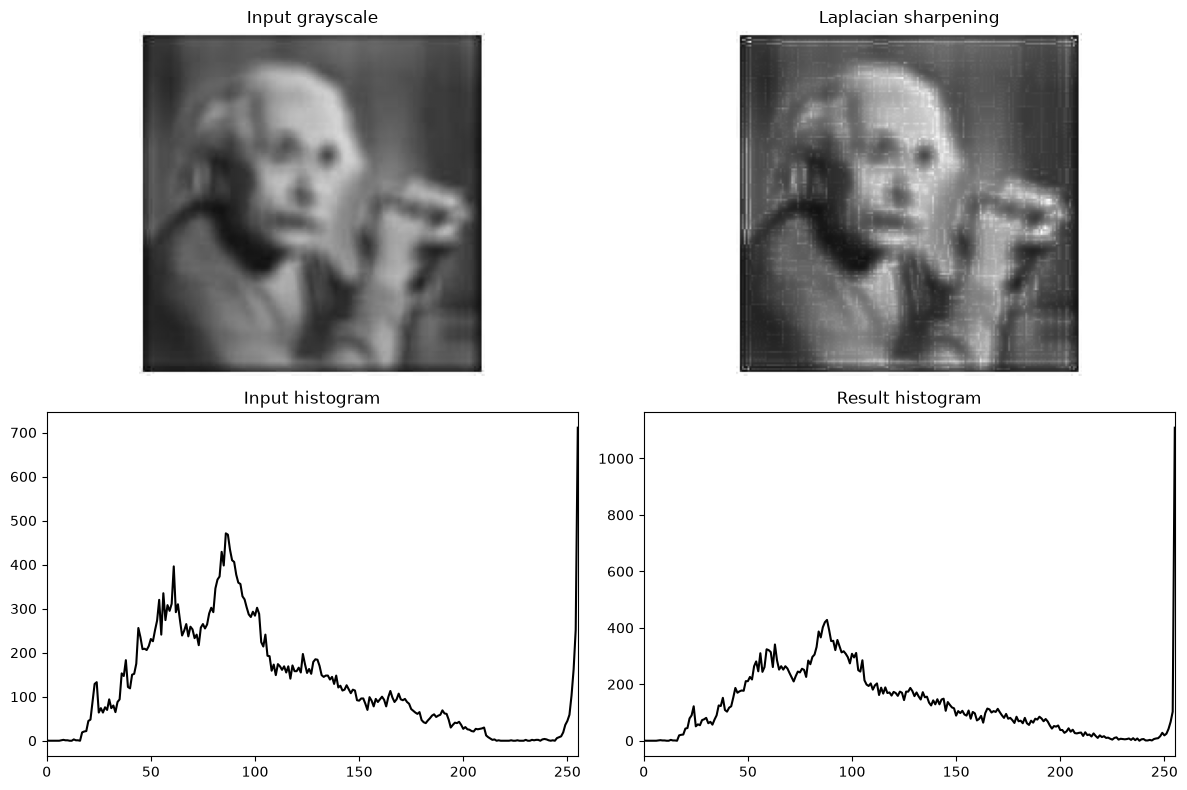

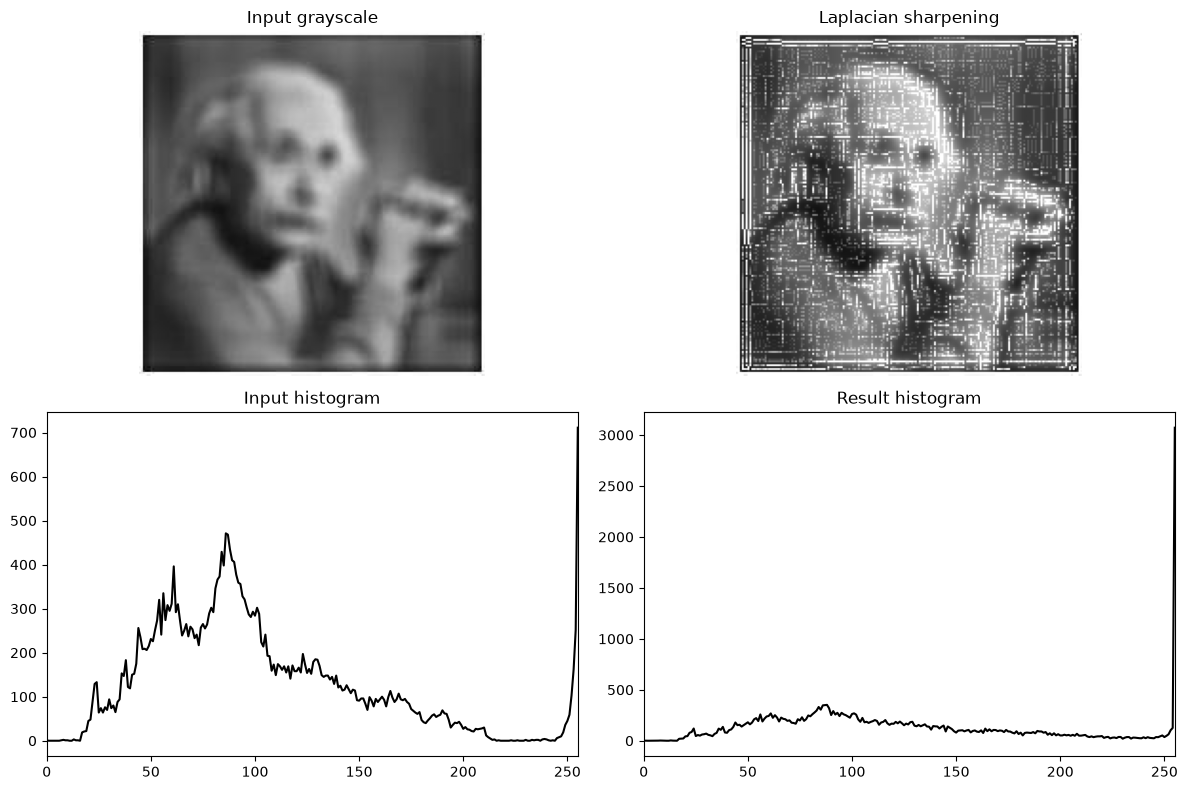

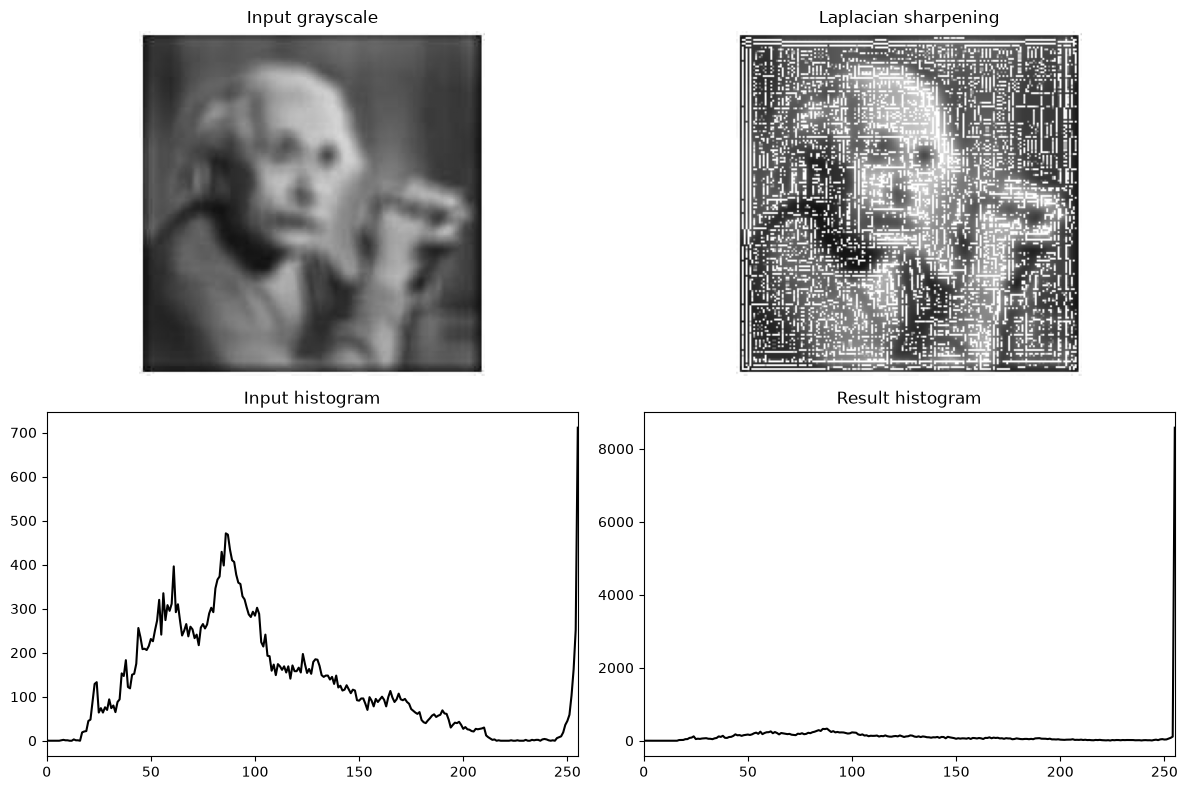

In [11]:
# Cell 13 - Laplacian sharpening
laplacian_kernel = [
    [-1, -1, -1], 
    [-1, 8, -1], 
    [-1, -1, -1]]

gray = load_grayscale('blurring1.jpg')
laplacian = convolve(gray, laplacian_kernel)
laplacian_sharp = [[clip(gray[y][x] + laplacian[y][x]) for x in range(len(gray[0]))] for y in range(len(gray))]
show_comparison(gray, laplacian_sharp, 'Laplacian sharpening')

laplacian = convolve(laplacian_sharp, laplacian_kernel)
laplacian_sharp1 = [[clip(laplacian_sharp[y][x] + laplacian[y][x]) for x in range(len(laplacian_sharp[0]))] for y in range(len(laplacian_sharp))]
show_comparison(gray, laplacian_sharp1, 'Laplacian sharpening')

laplacian = convolve(laplacian_sharp1, laplacian_kernel)
laplacian_sharp2 = [[clip(laplacian_sharp1[y][x] + laplacian[y][x]) for x in range(len(laplacian_sharp1[0]))] for y in range(len(laplacian_sharp1))]
show_comparison(gray, laplacian_sharp2, 'Laplacian sharpening')

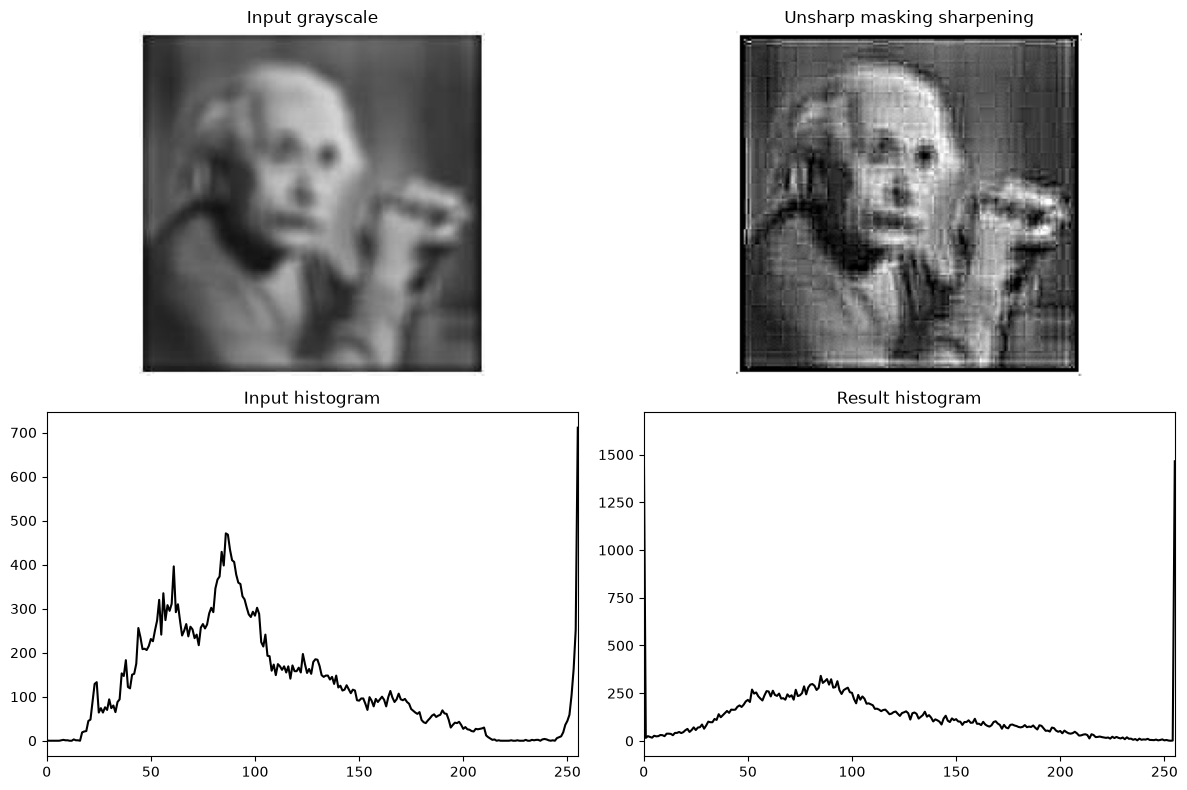

In [12]:
# Cell 14 - Sharpening dengan unsharp masking
gray = load_grayscale('blurring1.jpg')
blurred = convolve(gray, gaussian_kernel, divisor=273)
amount = 12
sharpened = [[clip(gray[y][x] + amount * (gray[y][x] - blurred[y][x])) for x in range(len(gray[0]))] for y in range(len(gray))]
show_comparison(gray, sharpened, 'Unsharp masking sharpening')

## Spatial domain: image arithmetic

## Frequency domain

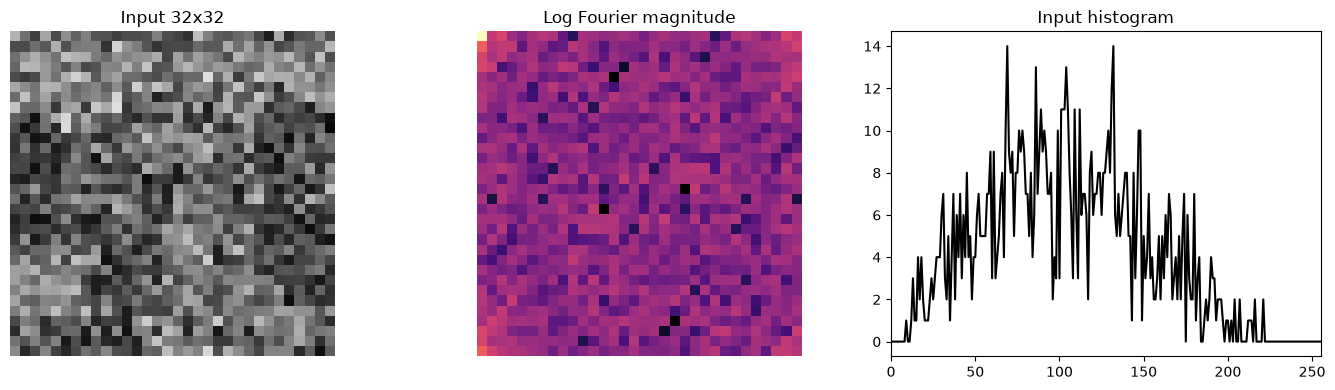

In [13]:
# Cell 17 - Fourier transform 2D manual (DFT)
# DFT O(N^4), sehingga citra diperkecil agar notebook tetap interaktif.
gray = load_grayscale('noise.png')
small = resize_nearest(gray, 32, 32)
N, M = len(small), len(small[0])
dft = [[sum(small[y][x] * cmath.exp(-2j * math.pi * (u * x / M + v * y / N)) for y in range(N) for x in range(M)) for u in range(M)] for v in range(N)]
magnitude = [[math.log(1 + abs(dft[v][u])) for u in range(M)] for v in range(N)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(small, cmap='gray', vmin=0, vmax=255); axes[0].set_title('Input 32x32')
axes[1].imshow(magnitude, cmap='magma'); axes[1].set_title('Log Fourier magnitude')
axes[2].plot(make_histogram(small), color='black'); axes[2].set_title('Input histogram'); axes[2].set_xlim(0, 255)
axes[0].axis('off'); axes[1].axis('off'); plt.tight_layout(); plt.show()

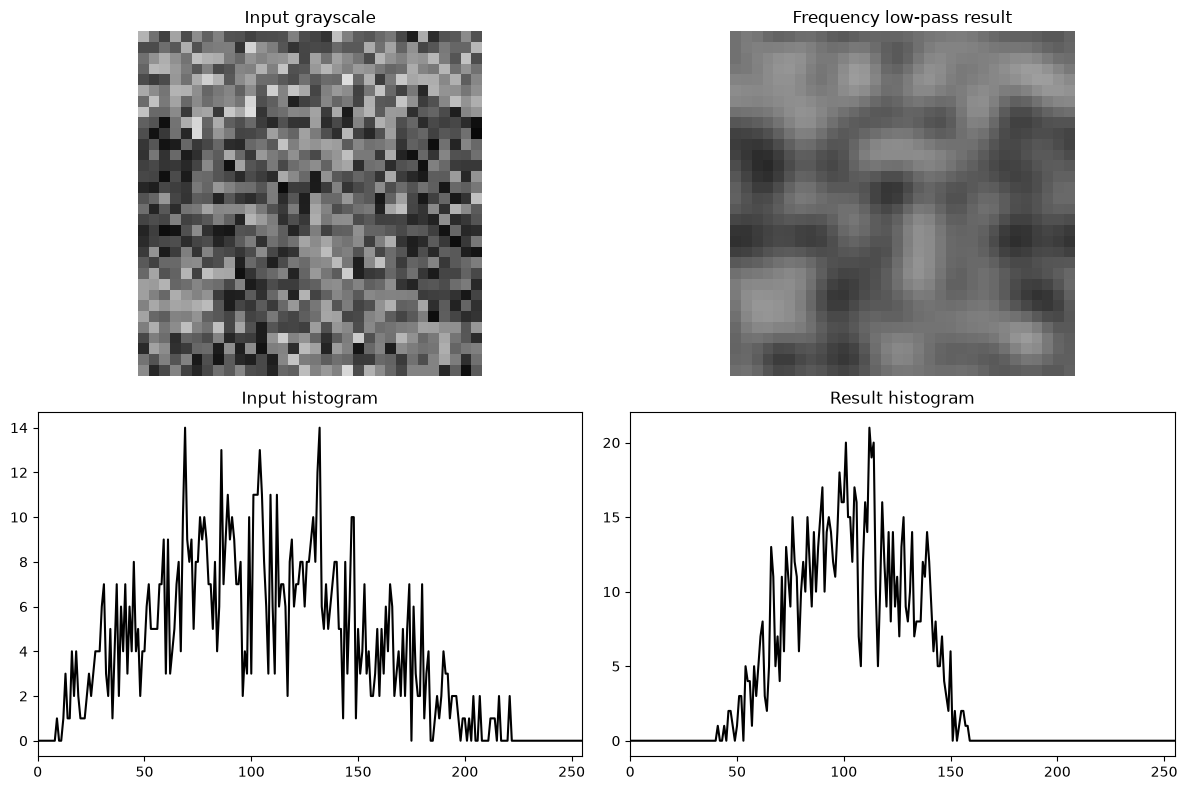

In [14]:
# Cell 18 - Low-pass filter pada domain frekuensi dan inverse DFT
cutoff = 6
gray = load_grayscale('toosharpened.png')
low_pass_dft = [[dft[v][u] if math.sqrt((u - M / 2) ** 2 + (v - N / 2) ** 2) <= cutoff else 0j for u in range(M)] for v in range(N)]
# Shift frekuensi untuk membentuk mask visual; DFT asli berada di pojok. 
centered = [[dft[(v + N // 2) % N][(u + M // 2) % M] for u in range(M)] for v in range(N)]
filtered_centered = [[centered[v][u] if math.sqrt((u - M / 2) ** 2 + (v - N / 2) ** 2) <= cutoff else 0j for u in range(M)] for v in range(N)]
low_pass_dft = [[filtered_centered[(v + N // 2) % N][(u + M // 2) % M] for u in range(M)] for v in range(N)]
low_pass = [[clip((sum(low_pass_dft[v][u] * cmath.exp(2j * math.pi * (u * x / M + v * y / N)) for v in range(N) for u in range(M)) / (N * M)).real) for x in range(M)] for y in range(N)]
show_comparison(small, low_pass, 'Frequency low-pass result')

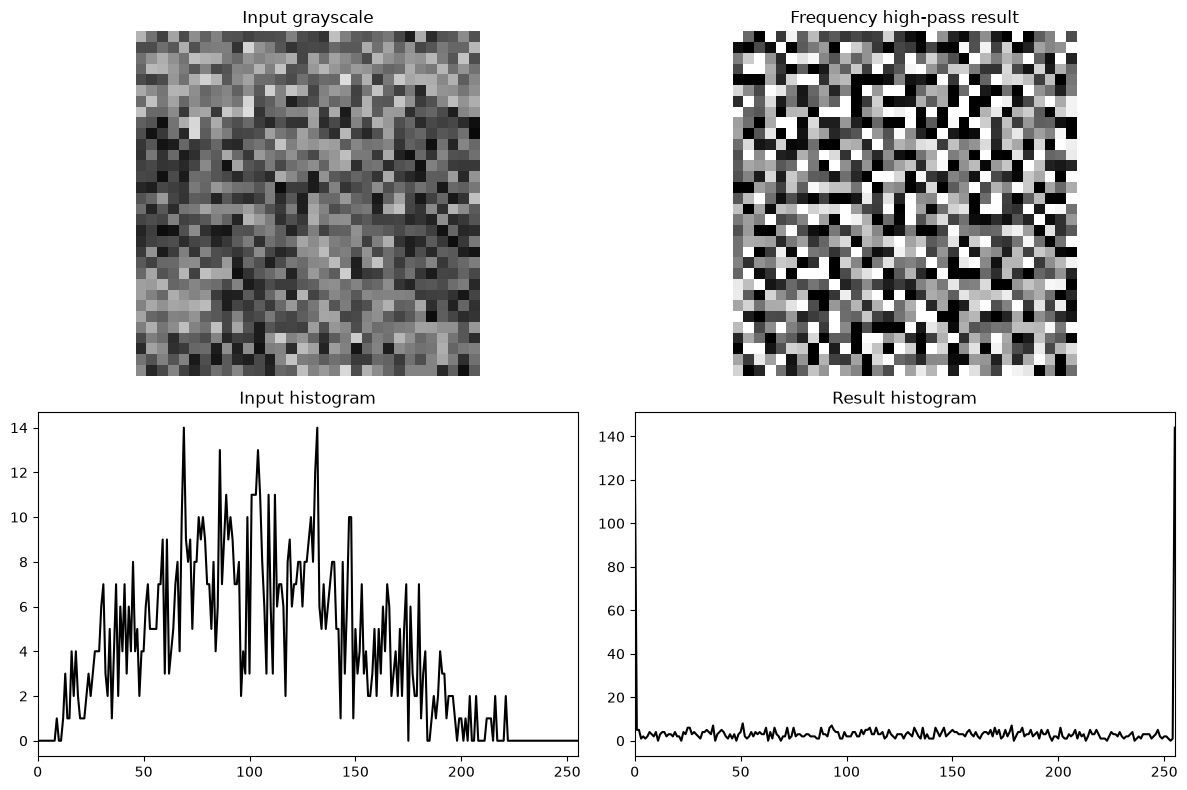

In [15]:
# Cell 19 - High-pass filter pada domain frekuensi dan inverse DFT
gray = load_grayscale('toosharpened.png')
high_pass_dft = [[centered[v][u] if math.sqrt((u - M / 2) ** 2 + (v - N / 2) ** 2) > cutoff else 0j for u in range(M)] for v in range(N)]
high_pass_dft = [[high_pass_dft[(v + N // 2) % N][(u + M // 2) % M] for u in range(M)] for v in range(N)]
high_pass_raw = [[(sum(high_pass_dft[v][u] * cmath.exp(2j * math.pi * (u * x / M + v * y / N)) for v in range(N) for u in range(M)) / (N * M)).real for x in range(M)] for y in range(N)]    
high_pass = [[clip(128 + 3 * high_pass_raw[y][x]) for x in range(M)] for y in range(N)]
show_comparison(small, high_pass, 'Frequency high-pass result')    